# Gemini Dataset: Cleaning & Analysis

This notebook cleans the synthetic Ferritic/Martensitic steel dataset generated by
Gemini, then checks it against known metallurgical trends.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", context="paper", font="sans-serif")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'sans-serif'
})


## 1. Cleaning the data

Gemini's output had its own set of issues to fix: iron content was given as the text
`"Balance"` in some rows instead of a number, hardness values mixed Brinell (HB) and
Rockwell C (HRC) scales, and a few unit/negative-value errors were present, same as the
other datasets.


In [2]:
def clean_gemini_dataset(filepath):
    """
    Cleans the Gemini dataset.

    - Standardizes column names to match the shared schema
    - Solves the "Balance" entries by calculating Fe_wt%% as 100 minus the other elements
    - Converts mixed HB/HRC hardness scales to a single HV column
    - Fixes unit errors in elastic modulus and removes negative values
    - Imputes remaining gaps with the column median (numeric) or mode (categorical)
    """
    if not os.path.exists(filepath):
        print(f"Error: File '{filepath}' not found.")
        return None

    df = pd.read_csv(filepath)
    print(f"Processing '{filepath}' | Initial shape: {df.shape}")

    rename_map = {
        'Phase_Ferrite_Vol%': 'Ferrite_Vol_%',
        'Phase_Martensite_Vol%': 'Martensite_Vol_%',
        'Yield_Strength_MPa': 'YS_MPa',
        'UTS_MPa': 'UTS_MPa',
        'Elastic_Modulus_GPa': 'Modulus_GPa',
        'Elongation_%': 'Elongation_%',
        'Hardness_Value': 'Hardness_Value',
        'Hardness_Scale': 'Hardness_Scale',
        'Heat_Treat_Temp_C': 'Heat_Treat_Temp_C',
        'Heat_Treat_Time_h': 'Heat_Treat_Time_h'
    }
    df.rename(columns=rename_map, inplace=True)

    # fill gaps in composition first, so the "Balance" calculation below is accurate
    comp_cols = ['C_wt%', 'Cr_wt%', 'Mn_wt%', 'Ni_wt%', 'Mo_wt%']
    for col in comp_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # solve Fe_wt% = 100 - sum(other elements) wherever it says "Balance"
    if 'Fe_wt%' in df.columns:
        df['Fe_wt%'] = df['Fe_wt%'].astype(object)  # allow mixed text/number during the fix below
        mask_balance = df['Fe_wt%'].astype(str).str.contains('Balance', case=False, na=False)
        if mask_balance.any():
            other_elements_sum = df.loc[mask_balance, comp_cols].sum(axis=1)
            df.loc[mask_balance, 'Fe_wt%'] = 100 - other_elements_sum
            print(f"  - Calculated iron content for {mask_balance.sum()} rows.")
        df['Fe_wt%'] = pd.to_numeric(df['Fe_wt%'], errors='coerce')

    # hardness: HB is roughly equal to HV for steel, HRC needs conversion
    if 'Hardness_Value' in df.columns and 'Hardness_Scale' in df.columns:
        df['Hardness_Scale'] = df['Hardness_Scale'].astype(str).str.upper().str.strip()

        def normalize_hardness_gemini(row):
            val = row['Hardness_Value']
            scale = row['Hardness_Scale']
            if pd.isna(val):
                return np.nan
            if scale == 'HB':
                return val
            elif scale == 'HRC':
                return (9.0 * val) + 55.0
            return val

        df['Hardness_HV'] = df.apply(normalize_hardness_gemini, axis=1)
        df.drop(columns=['Hardness_Value', 'Hardness_Scale'], inplace=True)
        print("  - Standardized hardness to a single 'Hardness_HV' column.")

    # unit fix: modulus values over 1000 are in MPa, not GPa
    if 'Modulus_GPa' in df.columns:
        mask_units = df['Modulus_GPa'] > 1000
        if mask_units.any():
            df.loc[mask_units, 'Modulus_GPa'] = df.loc[mask_units, 'Modulus_GPa'] / 1000.0

    # remove physically impossible negative values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in [c for c in numeric_cols if 'Temp' not in c]:
        df.loc[df[col] < 0, col] = np.nan

    # fill remaining gaps
    for col in numeric_cols:
        if col in df.columns and df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])

    df['Source'] = 'Gemini'
    return df


filename = '../data/raw/gemini.csv'
if os.path.exists(filename):
    gemini_clean = clean_gemini_dataset(filename)
    if gemini_clean is not None:
        gemini_clean.to_csv('../data/cleaned/cleaned_gemini.csv', index=False)
        print("\nSaved cleaned data to 'cleaned_Gemini.csv'.")
        print(gemini_clean[['Alloy_Type', 'Fe_wt%', 'C_wt%', 'Cr_wt%']].head(3))
        print(gemini_clean[['Alloy_Type', 'Hardness_HV']].head(3))


Processing '../data/raw/gemini.csv' | Initial shape: (70, 21)
  - Calculated iron content for 70 rows.
  - Standardized hardness to a single 'Hardness_HV' column.

Saved cleaned data to 'cleaned_Gemini.csv'.
    Alloy_Type  Fe_wt%  C_wt%  Cr_wt%
0     Ferritic   87.98   0.02    11.5
1  Martensitic   87.15   0.15    12.0
2     Ferritic   83.15   0.05    16.2
    Alloy_Type  Hardness_HV
0     Ferritic        145.0
1  Martensitic        460.0
2     Ferritic        160.0


## 2. Summary statistics


In [3]:
filename = '../data/cleaned/cleaned_gemini.csv'
if os.path.exists(filename):
    df = pd.read_csv(filename)

    target_cols = [
        'YS_MPa', 'UTS_MPa', 'Elongation_%',
        'Hardness_HV', 'Ferrite_Vol_%', 'Modulus_GPa'
    ]
    existing_cols = [c for c in target_cols if c in df.columns]
    stats_df = df[existing_cols]

    summary_stats = stats_df.describe().T
    summary_stats['Median'] = stats_df.median()
    summary_stats['Mode'] = stats_df.mode().iloc[0]
    summary_stats['Skewness'] = stats_df.skew()

    final_stats = summary_stats[['mean', 'Median', 'Mode', 'std', 'min', 'max', 'Skewness']]
    print(final_stats.round(2))

    final_stats.round(2).to_csv('../data/cleaned/gemini_statistics_summary.csv')
else:
    print(f"'{filename}' not found. Run the cleaning cell first.")


                 mean  Median   Mode     std    min     max  Skewness
YS_MPa         559.24   462.5  462.5  270.74  240.0  1110.0      0.56
UTS_MPa        784.24   677.5  400.0  314.55  400.0  1450.0      0.61
Elongation_%    18.01    18.0   18.0    6.96    6.0    30.5      0.03
Hardness_HV    316.76   343.0  343.0  153.13  130.0   532.0      0.08
Ferrite_Vol_%   50.80    12.0  100.0   47.60    0.0   100.0      0.05
Modulus_GPa    201.54   202.0  200.0    7.61  165.0   210.0     -2.66


## 3. Exploratory plots


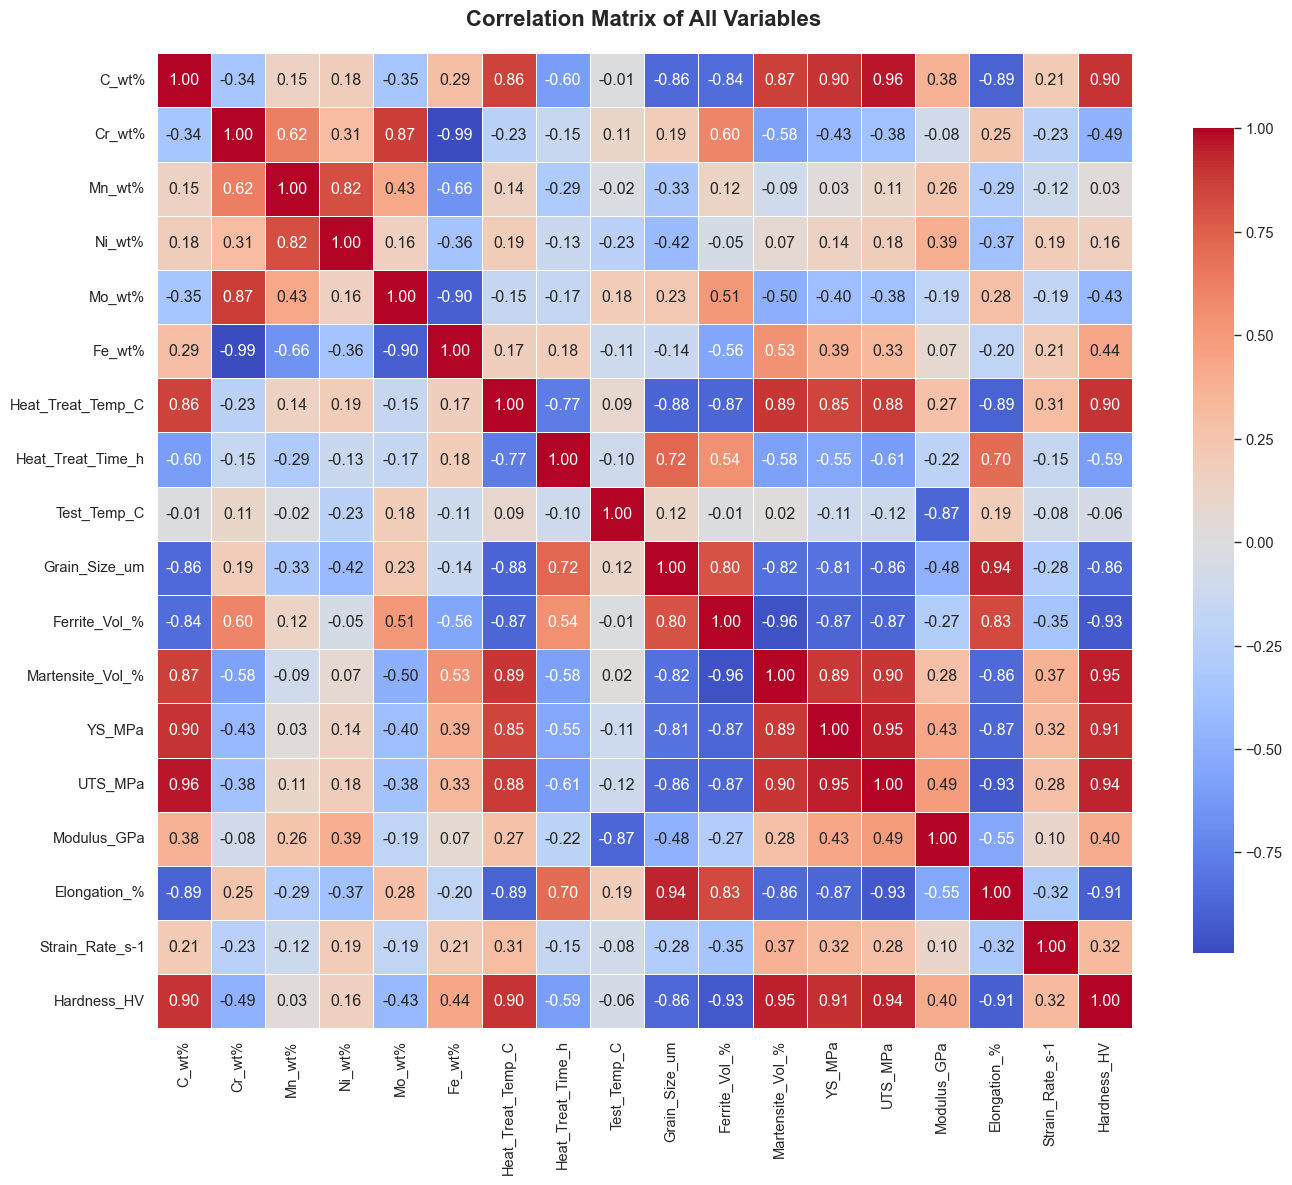

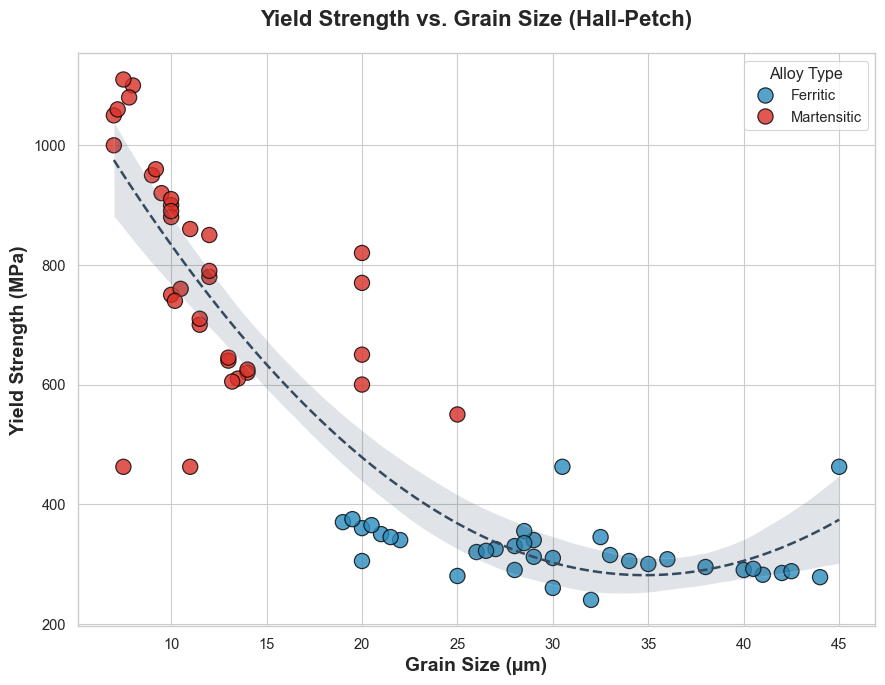

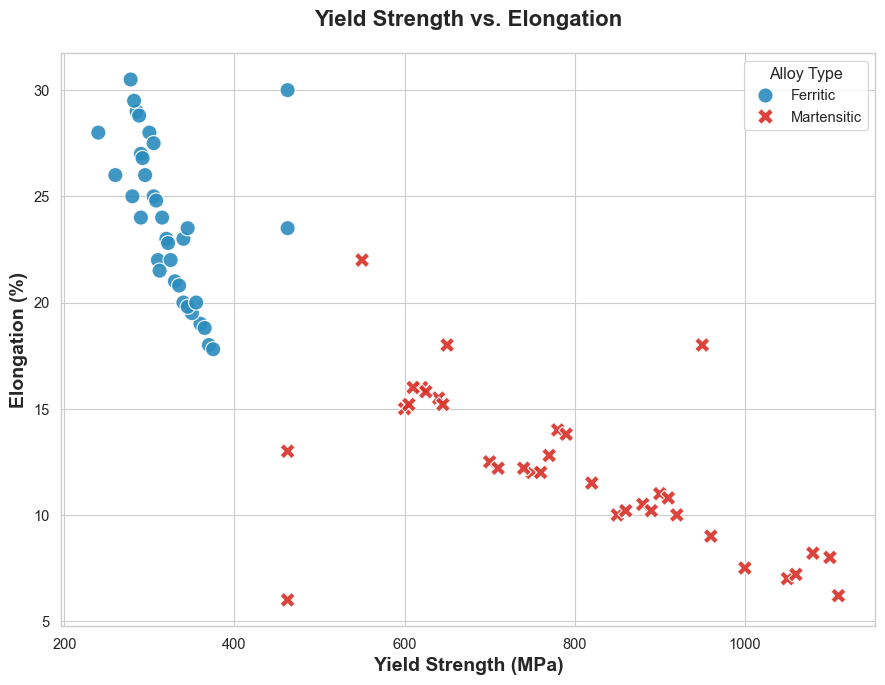

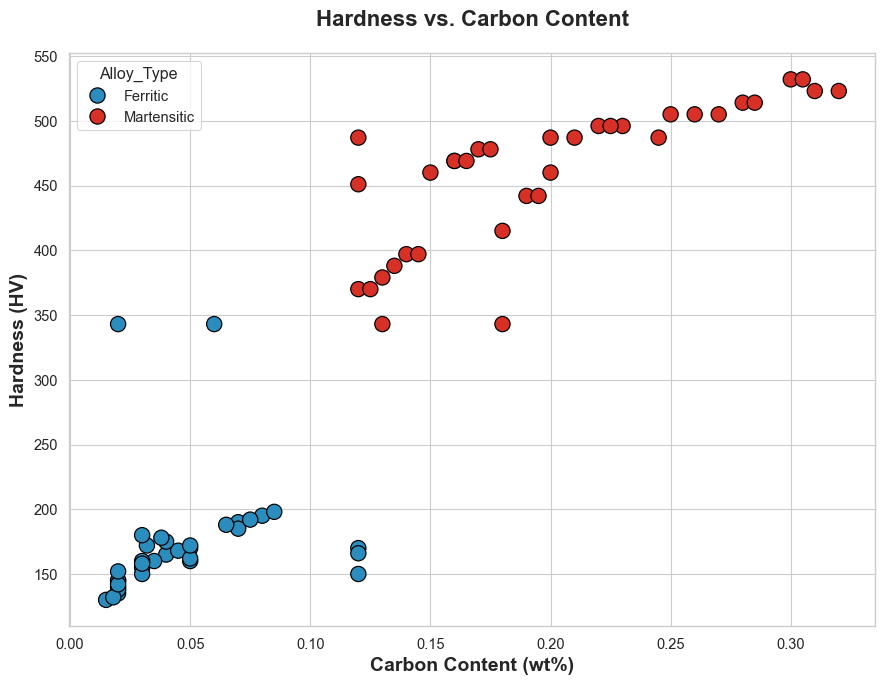

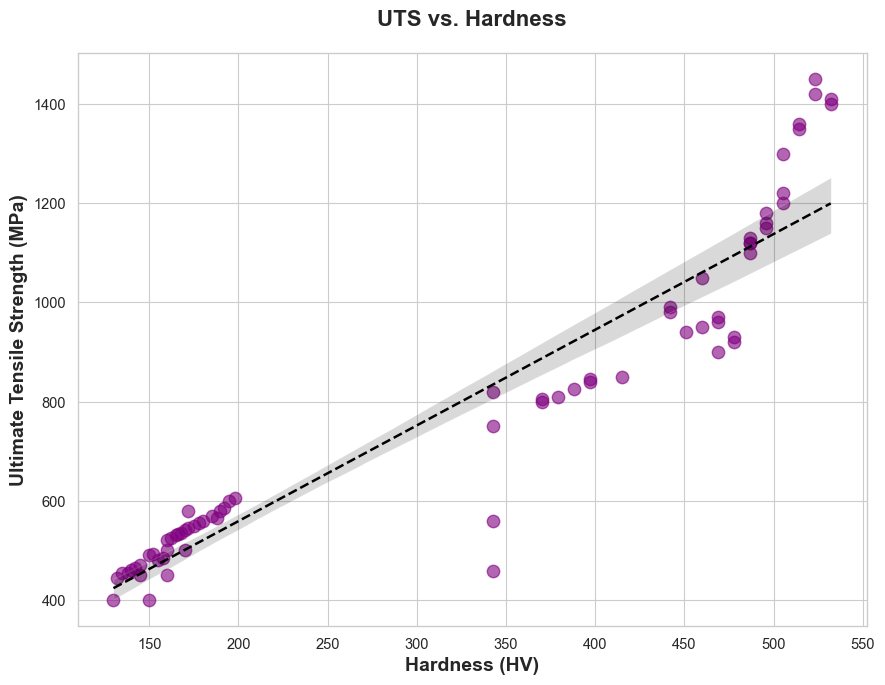

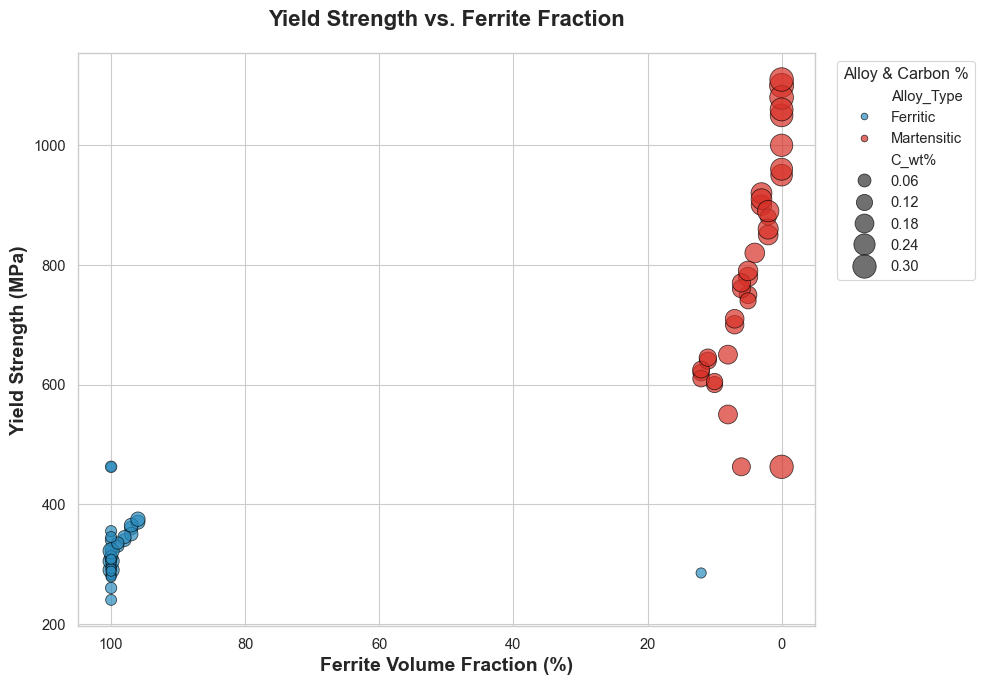

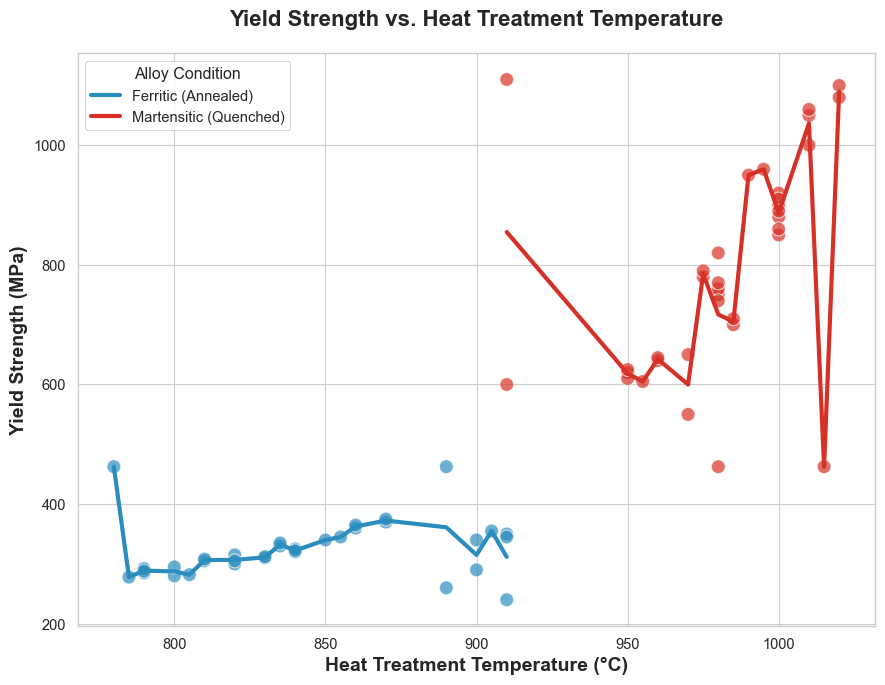

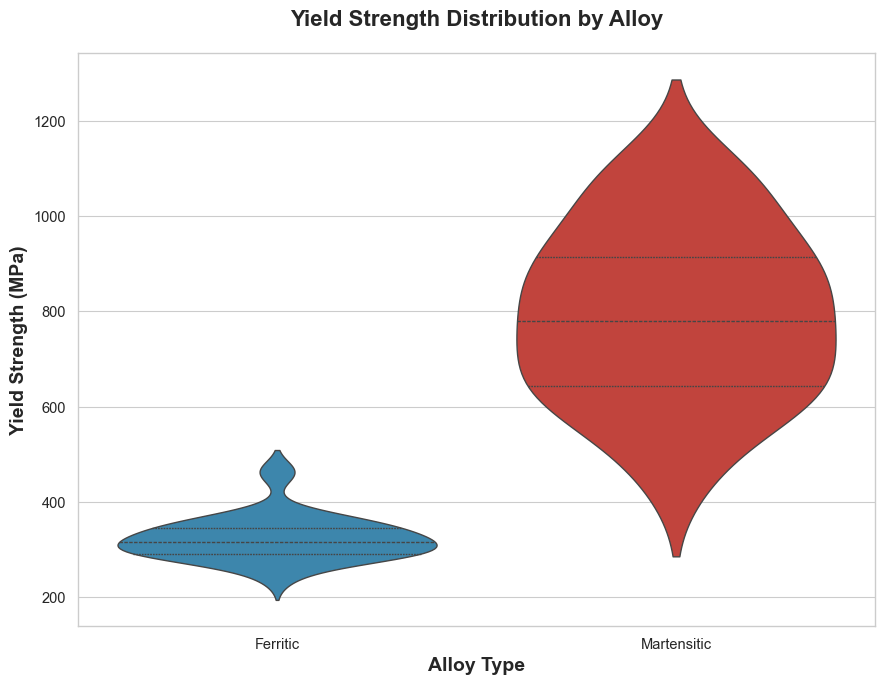

In [4]:
filename = '../data/cleaned/cleaned_gemini.csv'

if os.path.exists(filename):
    df = pd.read_csv(filename)

    sns.set_theme(style="whitegrid", context="paper", font="sans-serif", font_scale=1.2)
    custom_palette = {"Ferritic": "#2b8cbe", "Martensitic": "#d73027"}
    unique_classes = df['Alloy_Type'].unique()
    for cls in unique_classes:
        if cls not in custom_palette:
            custom_palette[cls] = "#95a5a6"

    numeric_df = df.select_dtypes(include=[np.number])
    if 'ID' in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=['ID'])

    plt.figure(figsize=(14, 12))
    sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
                center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
    plt.title('Correlation Matrix of All Variables', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    if 'Grain_Size_um' in df.columns:
        plt.figure(figsize=(9, 7))
        sns.scatterplot(data=df, x='Grain_Size_um', y='YS_MPa', hue='Alloy_Type',
                        palette=custom_palette, s=120, edgecolor='black', alpha=0.8)
        sns.regplot(data=df, x='Grain_Size_um', y='YS_MPa', scatter=False,
                    order=2, color='#34495e', line_kws={'linestyle':'--'})
        plt.title('Yield Strength vs. Grain Size (Hall-Petch)', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Grain Size (\u00b5m)', fontsize=14, fontweight='bold')
        plt.ylabel('Yield Strength (MPa)', fontsize=14, fontweight='bold')
        plt.legend(title='Alloy Type')
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(9, 7))
    sns.scatterplot(data=df, x='YS_MPa', y='Elongation_%', hue='Alloy_Type',
                    palette=custom_palette, style='Alloy_Type', s=120, alpha=0.9)
    plt.title('Yield Strength vs. Elongation', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Yield Strength (MPa)', fontsize=14, fontweight='bold')
    plt.ylabel('Elongation (%)', fontsize=14, fontweight='bold')
    plt.legend(title='Alloy Type')
    plt.tight_layout()
    plt.show()

    if 'C_wt%' in df.columns:
        plt.figure(figsize=(9, 7))
        sns.scatterplot(data=df, x='C_wt%', y='Hardness_HV', hue='Alloy_Type',
                        palette=custom_palette, s=120, edgecolor='black')
        plt.title('Hardness vs. Carbon Content', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Carbon Content (wt%)', fontsize=14, fontweight='bold')
        plt.ylabel('Hardness (HV)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(9, 7))
    sns.regplot(data=df, x='Hardness_HV', y='UTS_MPa',
                scatter_kws={'s': 80, 'alpha': 0.6, 'color':'purple'},
                line_kws={'color':'black', 'linestyle':'--'})
    plt.title('UTS vs. Hardness', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Hardness (HV)', fontsize=14, fontweight='bold')
    plt.ylabel('Ultimate Tensile Strength (MPa)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    if 'Ferrite_Vol_%' in df.columns and 'C_wt%' in df.columns:
        plt.figure(figsize=(10, 7))
        sns.scatterplot(data=df, x='Ferrite_Vol_%', y='YS_MPa', hue='Alloy_Type',
                        size='C_wt%', sizes=(50, 300), palette=custom_palette,
                        alpha=0.7, edgecolor='black')
        plt.title('Yield Strength vs. Ferrite Fraction', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Ferrite Volume Fraction (%)', fontsize=14, fontweight='bold')
        plt.ylabel('Yield Strength (MPa)', fontsize=14, fontweight='bold')
        plt.gca().invert_xaxis()
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Alloy & Carbon %")
        plt.tight_layout()
        plt.show()

    if 'Heat_Treat_Temp_C' in df.columns:
        plt.figure(figsize=(9, 7))
        df['Process_Label'] = df['Alloy_Type'].map({
            'Ferritic': 'Ferritic (Annealed)',
            'Martensitic': 'Martensitic (Quenched)'
        }).fillna(df['Alloy_Type'])

        sns.scatterplot(data=df, x='Heat_Treat_Temp_C', y='YS_MPa', hue='Process_Label',
                        palette={'Ferritic (Annealed)': '#2b8cbe', 'Martensitic (Quenched)': '#d73027'},
                        s=100, alpha=0.7, legend=False)
        sns.lineplot(data=df, x='Heat_Treat_Temp_C', y='YS_MPa', hue='Process_Label',
                     palette={'Ferritic (Annealed)': '#2b8cbe', 'Martensitic (Quenched)': '#d73027'},
                     marker=None, linewidth=3, errorbar=None)

        plt.title('Yield Strength vs. Heat Treatment Temperature', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Heat Treatment Temperature (\u00b0C)', fontsize=14, fontweight='bold')
        plt.ylabel('Yield Strength (MPa)', fontsize=14, fontweight='bold')
        plt.legend(title='Alloy Condition')
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(9, 7))
    sns.violinplot(data=df, x='Alloy_Type', y='YS_MPa', hue='Alloy_Type',
                   palette=custom_palette, inner="quartile", dodge=False)
    plt.title('Yield Strength Distribution by Alloy', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Alloy Type', fontsize=14, fontweight='bold')
    plt.ylabel('Yield Strength (MPa)', fontsize=14, fontweight='bold')
    plt.legend([],[], frameon=False)
    plt.tight_layout()
    plt.show()

else:
    print(f"'{filename}' not found.")


## Observations

Gemini's data showed reasonably strong physical grounding, with correct correlation
signs between hardness/carbon content and between yield strength/elongation. The
Hall-Petch trend was present but noisier than Claude's. The heat treatment vs. strength
relationship captured the general hardening effect of quenching for martensite, though
with more scatter than expected from a controlled experiment.
